In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!nvidia-smi

Thu Aug 13 05:10:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("Policy:", mixed_precision.global_policy())

Policy: <DTypePolicy "mixed_float16">


In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
import os

BASE_PATH = "/content/drive/MyDrive/Thesis"

HAM_PATH = os.path.join(BASE_PATH, "HAM10000")
PAD_PATH = os.path.join(BASE_PATH, "PAD-UFES-20")

HAM_IMAGE_DIR = os.path.join(HAM_PATH, "images")
PAD_IMAGE_DIR = os.path.join(PAD_PATH, "images")

print("HAM:", os.listdir(HAM_PATH))
print("PAD:", os.listdir(PAD_PATH))

HAM: ['images', 'HAM10000_metadata.csv']
PAD: ['metadata.csv', 'images']


In [7]:
import pandas as pd

ham = pd.read_csv(
    os.path.join(HAM_PATH, "HAM10000_metadata.csv")
)

print("Shape:", ham.shape)
print(ham.head())

Shape: (10015, 8)
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

        dataset  
0  vidir_modern  
1  vidir_modern  
2  vidir_modern  
3  vidir_modern  
4  vidir_modern  


In [8]:
print(ham["dx"].unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [9]:
print(ham["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [10]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]

ham_4 = ham[
    ham["dx"].isin(HAM_CLASSES)
].copy()

print("HAM images after filtering:", len(ham_4))
print(ham_4["dx"].value_counts())

HAM images after filtering: 8659
dx
nv       6705
mel      1113
bcc       514
akiec     327
Name: count, dtype: int64


In [11]:
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

print(ham_4["label"].value_counts())

label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64


In [12]:
ham_4["image_path"] = ham_4["image_id"].apply(
    lambda x: os.path.join(HAM_IMAGE_DIR, x + ".jpg")
)

In [13]:
print(
    ham_4[
        ["image_id", "dx", "label", "image_path"]
    ].head()
)

          image_id   dx label  \
64    ISIC_0024698   nv   NEV   
1210  ISIC_0024693   nv   NEV   
1211  ISIC_0025964  mel   MEL   
1212  ISIC_0030623  mel   MEL   
1213  ISIC_0027190  mel   MEL   

                                             image_path  
64    /content/drive/MyDrive/Thesis/HAM10000/images/...  
1210  /content/drive/MyDrive/Thesis/HAM10000/images/...  
1211  /content/drive/MyDrive/Thesis/HAM10000/images/...  
1212  /content/drive/MyDrive/Thesis/HAM10000/images/...  
1213  /content/drive/MyDrive/Thesis/HAM10000/images/...  


In [14]:
ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)

print(ham_4["exists"].value_counts())

exists
True    8659
Name: count, dtype: int64


In [15]:
print(os.listdir(PAD_PATH))

['metadata.csv', 'images']


In [16]:
pad = pd.read_csv(
    os.path.join(PAD_PATH, "metadata.csv")
)

print("Shape:", pad.shape)
print(pad.head())

Shape: (2298, 26)
  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
0    8       NaN     NaN                 NaN  ...        NaN        NEV   
1   55     False  FEMALE                True  ...        5.0        BCC   
2   77       NaN     NaN                 NaN  ...        NaN        ACK   
3   75       NaN     NaN                 NaN  ...        NaN        ACK   
4   79     False    MALE                True  ...        5.0        BCC   

    itch   grew   hurt  changed  bleed elevation                 img

In [17]:
print(pad["diagnostic"].unique())
print(pad["diagnostic"].value_counts())

['NEV' 'BCC' 'ACK' 'SEK' 'SCC' 'MEL']
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [18]:
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

pad_4 = pad[
    pad["diagnostic"].isin(PAD_CLASSES)
].copy()

print("PAD images after filtering:", len(pad_4))
print(pad_4["diagnostic"].value_counts())

PAD images after filtering: 1871
diagnostic
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [19]:
pad_4["label"] = pad_4["diagnostic"]

print(pad_4["label"].value_counts())

label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [20]:
print(os.listdir(PAD_IMAGE_DIR)[:10])

['PAT_1418_1452_948.png', 'PAT_810_1526_67.png', 'PAT_477_915_389.png', 'PAT_1420_1460_733.png', 'PAT_813_1619_543.png', 'PAT_1414_1432_969.png', 'PAT_1414_1429_53.png', 'PAT_471_909_353.png', 'PAT_471_909_394.png', 'PAT_478_1829_141.png']


In [22]:
pad_4["image_path"] = pad_4["img_id"].apply(
    lambda x: os.path.join(PAD_IMAGE_DIR, x + ".png")
)

In [23]:
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())

exists
False    1871
Name: count, dtype: int64


In [24]:
ham_classes = set(ham_4["label"].unique())
pad_classes = set(pad_4["label"].unique())

print("HAM classes:", sorted(ham_classes))
print("PAD classes:", sorted(pad_classes))

print("\nSame classes:", ham_classes == pad_classes)
print("Common:", sorted(ham_classes & pad_classes))

HAM classes: ['ACK', 'BCC', 'MEL', 'NEV']
PAD classes: ['ACK', 'BCC', 'MEL', 'NEV']

Same classes: True
Common: ['ACK', 'BCC', 'MEL', 'NEV']


In [25]:
ham_ids = set(ham_4["image_id"])

In [26]:
pad_ids = set(pad_4["img_id"])

In [27]:
overlap = ham_ids.intersection(pad_ids)

print("HAM images:", len(ham_ids))
print("PAD images:", len(pad_ids))
print("Common IDs:", len(overlap))

HAM images: 8659
PAD images: 1871
Common IDs: 0


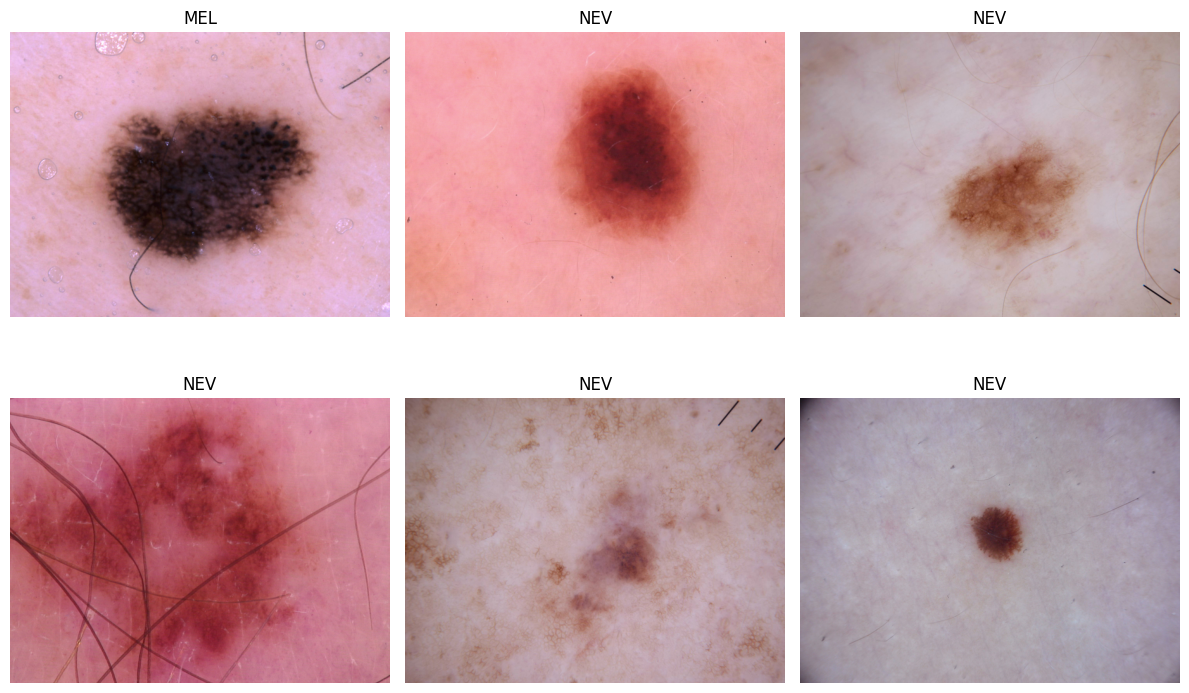

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

sample = ham_4.sample(6, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import os

# First remove the old image_path
if "image_path" in pad_4.columns:
    pad_4 = pad_4.drop(columns=["image_path"])

# Create the correct path
pad_4["image_path"] = pad_4["img_id"].apply(
    lambda x: os.path.join(PAD_IMAGE_DIR, x if x.endswith(".png") else x + ".png")
)

print(pad_4[["img_id", "image_path"]].head())

                  img_id                                         image_path
0  PAT_1516_1765_530.png  /content/drive/MyDrive/Thesis/PAD-UFES-20/imag...
1     PAT_46_881_939.png  /content/drive/MyDrive/Thesis/PAD-UFES-20/imag...
2  PAT_1545_1867_547.png  /content/drive/MyDrive/Thesis/PAD-UFES-20/imag...
3  PAT_1989_4061_934.png  /content/drive/MyDrive/Thesis/PAD-UFES-20/imag...
4   PAT_684_1302_588.png  /content/drive/MyDrive/Thesis/PAD-UFES-20/imag...


In [30]:
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())

exists
True    1871
Name: count, dtype: int64


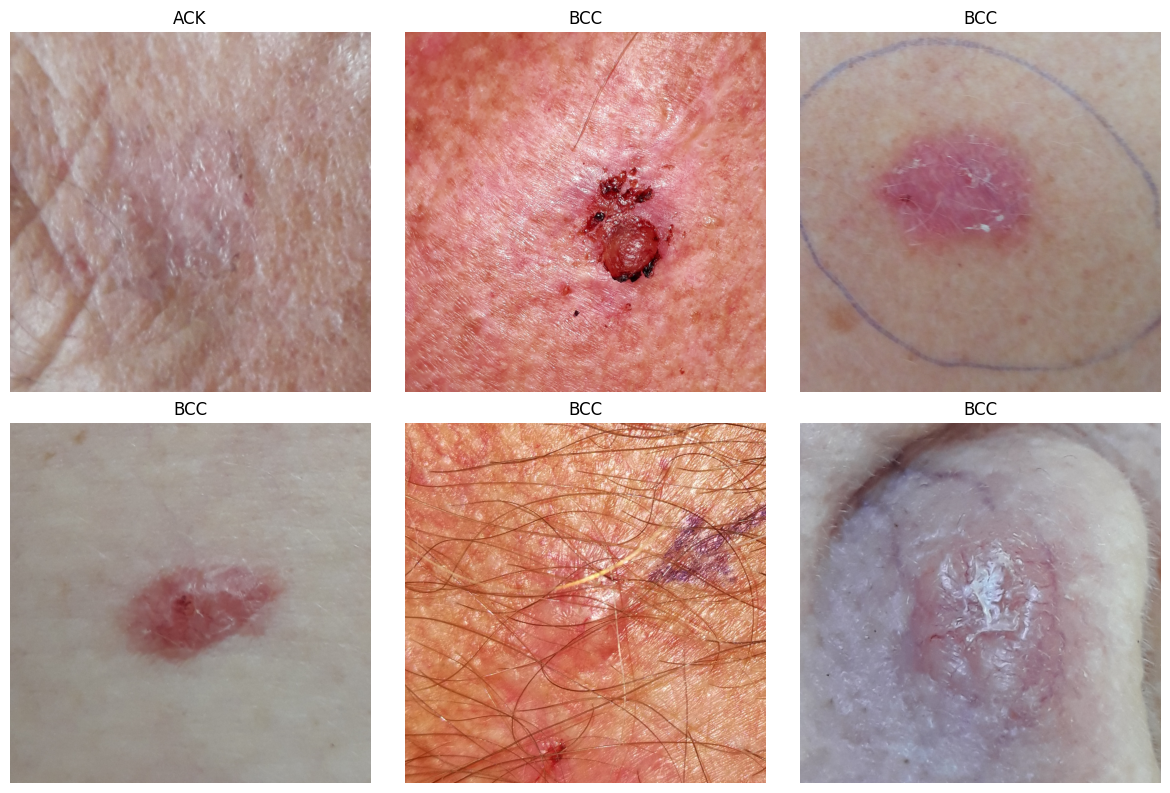

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

sample = pad_4.sample(6, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

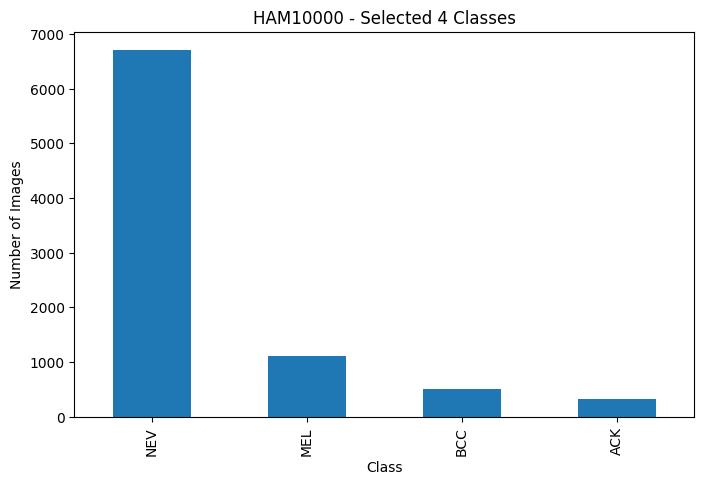

In [32]:
ham_4["label"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    title="HAM10000 - Selected 4 Classes"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

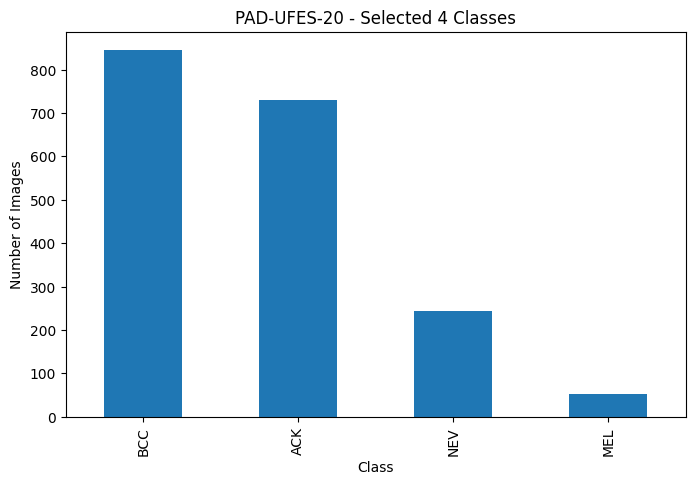

In [33]:
pad_4["label"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    title="PAD-UFES-20 - Selected 4 Classes"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [34]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        ham_4,
        groups=ham_4["lesion_id"]
    )
)

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))

Training: 6932
Validation: 1727


In [35]:
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

label_to_id = {
    "ACK": 0,
    "BCC": 1,
    "MEL": 2,
    "NEV": 3
}

train_df["label_id"] = train_df["label"].map(label_to_id)
val_df["label_id"] = val_df["label"].map(label_to_id)
pad_4["label_id"] = pad_4["label"].map(label_to_id)

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (250, 250)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest"
)

In [37]:
val_datagen = ImageDataGenerator()

In [38]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

Found 6932 validated image filenames belonging to 4 classes.


In [39]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

Found 1727 validated image filenames belonging to 4 classes.


In [40]:
x_batch, y_batch = next(train_generator)

print("Image batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

Image batch shape: (16, 250, 250, 3)
Label batch shape: (16, 4)


In [41]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.models import Model

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(250, 250, 3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

output = Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250, 250,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 250, 250,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 250, 250,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 250, 250,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 251, 251,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 125, 125,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 125, 125,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 125, 125,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 125, 125,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 125, 125,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 125, 125,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 125, 125,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 125, 125,  │        960 │ block1a_se_excit

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [43]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Thesis/best_ham_pad_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [45]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 3151s 7s/step - accuracy: 0.7742 - loss: 0.6027 - val_accuracy: 0.8014 - val_loss: 0.4821 - learning_rate: 0.0010
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 194s 446ms/step - accuracy: 0.8024 - loss: 0.5135 - val_accuracy: 0.8118 - val_loss: 0.4633 - learning_rate: 0.0010
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 186s 429ms/step - accuracy: 0.8076 - loss: 0.4949 - val_accuracy: 0.8188 - val_loss: 0.4526 - learning_rate: 0.0010
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 205s 436ms/step - accuracy: 0.8099 - loss: 0.4829 - val_accuracy: 0.8124 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 185s 426ms/step - accuracy: 0.8159 - loss: 0.4777 - val_accuracy: 0.8211 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 190s 438ms/step - accuracy: 0.8068 - loss: 0.4773 - val_accuracy: 0.8199 - val_loss: 0.4413 - learning_rate: 0.0010
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 185s 427ms/step - accuracy

In [46]:
print("Epochs completed:", len(history.history["accuracy"]))
print("Best validation accuracy:",
      max(history.history["val_accuracy"]))

Epochs completed: 16
Best validation accuracy: 0.827446460723877


In [47]:
import os

model_path = "/content/drive/MyDrive/Thesis/best_ham_pad_model.keras"

print("Best model exists:", os.path.exists(model_path))

Best model exists: True


In [48]:
from tensorflow.keras.models import load_model

best_model = load_model(model_path)

print("Best model loaded successfully.")

Best model loaded successfully.


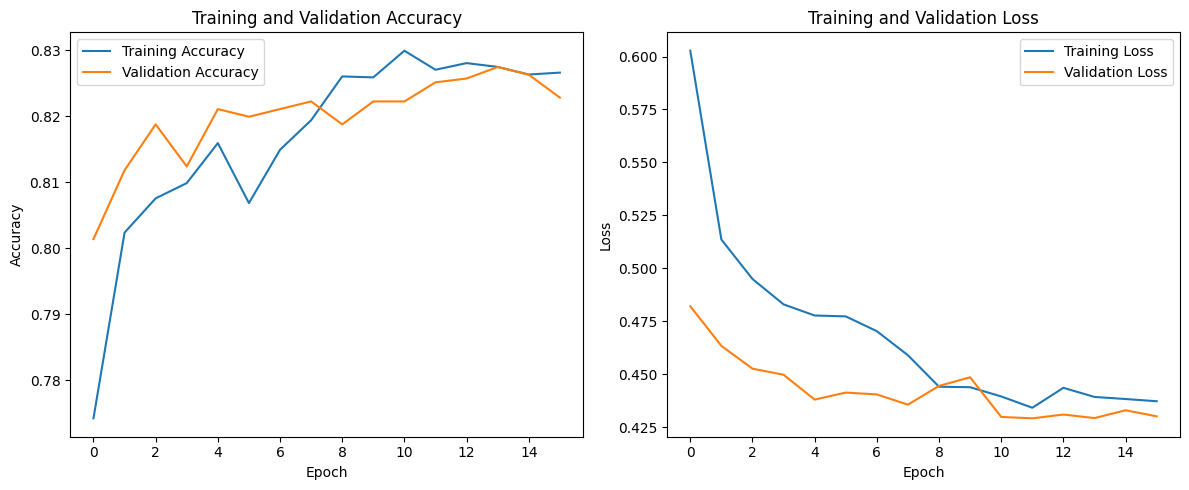

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/Thesis/best_ham_pad_model.keras"

best_model = load_model(MODEL_PATH)

print("Best model loaded successfully.")

Best model loaded successfully.


In [51]:
print("Model output shape:", best_model.output_shape)

Model output shape: (None, 4)


In [52]:
ham_val_loss, ham_val_accuracy = best_model.evaluate(
    val_generator,
    verbose=1
)

print("HAM Validation Accuracy:", ham_val_accuracy)

108/108 ━━━━━━━━━━━━━━━━━━━━ 86s 426ms/step - accuracy: 0.8274 - loss: 0.4292
HAM Validation Accuracy: 0.827446460723877


In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pad_datagen = ImageDataGenerator()

In [54]:
pad_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=(250, 250),
    batch_size=16,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

Found 1871 validated image filenames belonging to 4 classes.


In [55]:
pad_loss, pad_accuracy = best_model.evaluate(
    pad_generator,
    verbose=1
)

print("PAD-UFES-20 Cross-Dataset Accuracy:", pad_accuracy)
print("PAD-UFES-20 Loss:", pad_loss)

117/117 ━━━━━━━━━━━━━━━━━━━━ 854s 7s/step - accuracy: 0.2779 - loss: 2.2561
PAD-UFES-20 Cross-Dataset Accuracy: 0.2779262363910675
PAD-UFES-20 Loss: 2.2561252117156982


In [56]:
import numpy as np

pred_probs = best_model.predict(
    pad_generator,
    verbose=1
)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

true_classes = pad_generator.classes

117/117 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    true_classes,
    pred_classes
)

precision = precision_score(
    true_classes,
    pred_classes,
    average="macro",
    zero_division=0
)

recall = recall_score(
    true_classes,
    pred_classes,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    true_classes,
    pred_classes,
    average="macro",
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.27792624265098875
Precision: 0.37077912505625843
Recall   : 0.3838962530412979
F1 Score : 0.22949559753532478


In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         ACK       0.45      0.07      0.12       730
         BCC       0.79      0.27      0.40       845
         MEL       0.05      0.25      0.08        52
         NEV       0.19      0.95      0.32       244

    accuracy                           0.28      1871
   macro avg       0.37      0.38      0.23      1871
weighted avg       0.56      0.28      0.27      1871



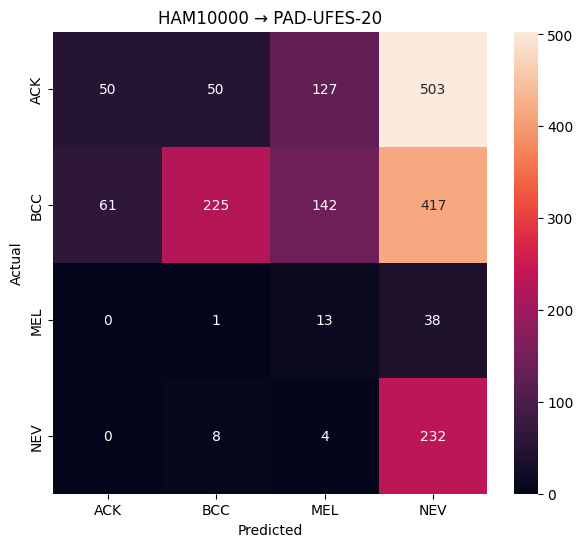

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HAM10000 → PAD-UFES-20")
plt.show()

In [60]:
print("CLASS_NAMES:", CLASS_NAMES)
print("Generator classes:", pad_generator.class_indices)

CLASS_NAMES: ['ACK', 'BCC', 'MEL', 'NEV']
Generator classes: {'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3}


In [61]:
print(pad_4["label"].value_counts())

label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [63]:
val_accuracy = max(history.history["val_accuracy"])

print("Best HAM Validation Accuracy:", val_accuracy)

Best HAM Validation Accuracy: 0.827446460723877


In [65]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_auc_score

true_onehot = to_categorical(
    true_classes,
    num_classes=len(CLASS_NAMES)
)

auc_score = roc_auc_score(
    true_onehot,
    pred_probs,
    multi_class="ovr",
    average="macro"
)

print("Macro AUC:", auc_score)

Macro AUC: 0.7059741625730275


In [66]:
baseline_results = {
    "HAM_Validation_Accuracy": val_accuracy,
    "PAD_Accuracy": accuracy,
    "PAD_Precision": precision,
    "PAD_Recall": recall,
    "PAD_F1": f1,
    "PAD_AUC": auc_score
}

print(baseline_results)

{'HAM_Validation_Accuracy': 0.827446460723877, 'PAD_Accuracy': 0.27792624265098875, 'PAD_Precision': 0.37077912505625843, 'PAD_Recall': 0.3838962530412979, 'PAD_F1': 0.22949559753532478, 'PAD_AUC': np.float64(0.7059741625730275)}
